# 🚢 Titanic Survival Prediction using Machine Learning

### Logistic Regression Model

## 📌 Project Overview

The Titanic Survival Prediction project uses machine learning to predict whether a passenger survived the Titanic disaster based on passenger information such as passenger class, gender, age, family details, and fare.

A Logistic Regression model is trained on the Titanic dataset and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

## 📊 Dataset Description

The Titanic dataset contains information about passengers who were aboard the RMS Titanic.

The dataset includes passenger details such as:

- Passenger class
- Gender
- Age
- Number of siblings or spouses
- Number of parents or children
- Fare
- Survival status

The target variable is `Survived`, where `0` represents did not survive and `1` represents survived.

## 1. Data Loading

The Titanic dataset is loaded into a Pandas DataFrame for analysis and machine learning.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Understanding

The dataset is examined to understand its size, structure, data types, and basic statistical information.

In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Missing Value Analysis

Missing values are identified to determine which columns require data cleaning before training the machine learning model.

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 4. Data Cleaning

Missing values are handled to prepare the dataset for machine learning.

- The `Cabin` column is removed because it contains a large number of missing values.
- Missing `Age` values are replaced with the median age.
- Missing `Embarked` values are replaced with the most frequent value.

In [6]:
df.drop("Cabin", axis = 1, inplace = True)

In [7]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipykernel_704/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [8]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_704/122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## 5. Categorical Data Encoding

Categorical variables are converted into numerical values so that they can be used by the machine learning model.

- `male` is encoded as `0`.
- `female` is encoded as `1`.
- `Embarked` categories are converted into numerical columns using one-hot encoding.

In [11]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [12]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True, dtype=int)

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1


## 6. Feature Selection

The relevant features are selected as input variables for the machine learning model.

Selected features:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`

The `Survived` column is used as the target variable.

In [14]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]

y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 6)
Target shape: (891,)


## 7. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used to train the model.
- 20% of the data is used to evaluate the model.
- `random_state=42` ensures reproducible results.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


## 8. Model Training

A Logistic Regression model is used to predict whether a passenger survived the Titanic disaster.

The model is trained using the training dataset.

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 9. Model Prediction

The trained Logistic Regression model is used to predict the survival outcomes for passengers in the test dataset.

In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


## 10. Model Evaluation

The performance of the Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8100558659217877
Accuracy Percentage: 81.00558659217877 %


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[92 13]
 [21 53]]


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



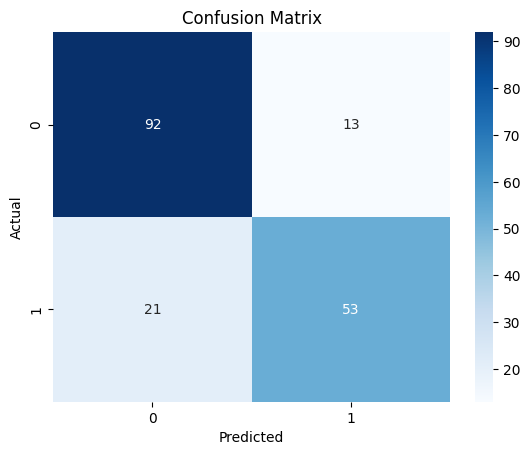

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 11. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to identify patterns and relationships in the Titanic dataset.

The visualizations examine survival distribution, gender, passenger class, and age in relation to survival.

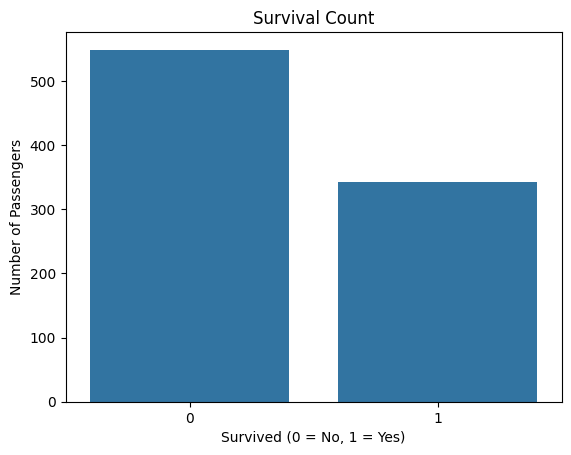

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

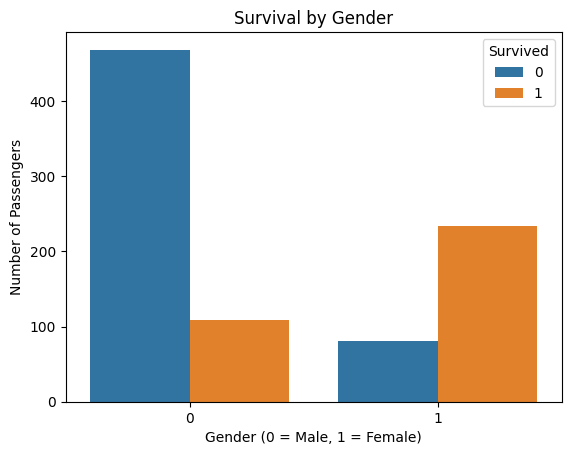

In [24]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender (0 = Male, 1 = Female)")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived")

plt.show()

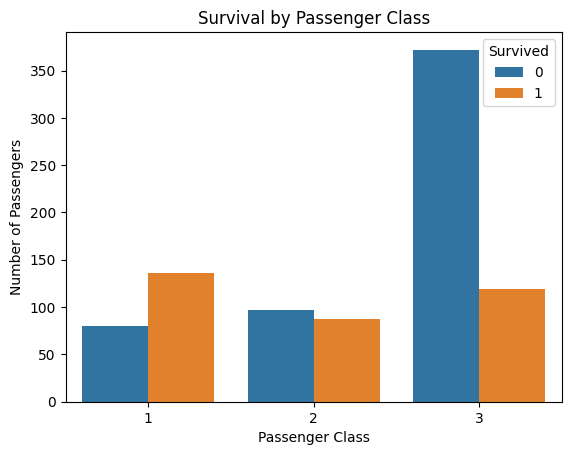

In [25]:
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived")

plt.show()

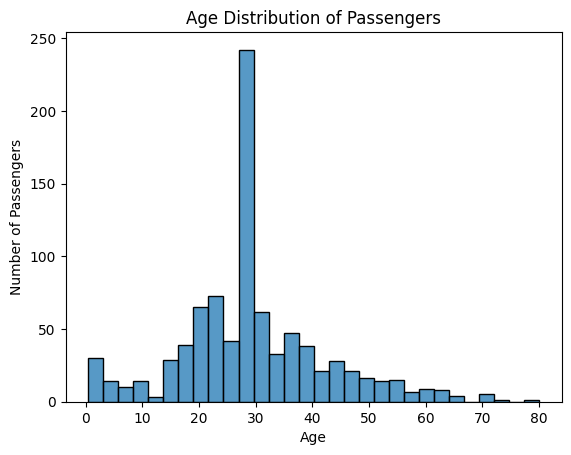

In [26]:
sns.histplot(data=df, x="Age", bins=30)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

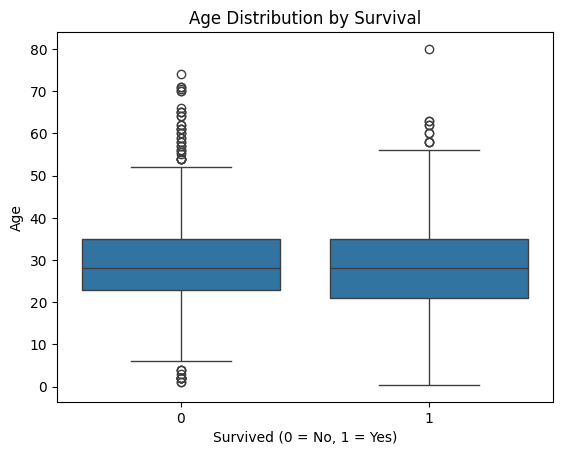

In [27]:
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

## 12. Feature Importance

The coefficients of the Logistic Regression model are analyzed to understand the direction and relative influence of the selected features on the prediction.

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance)

  Feature  Coefficient
1     Sex     2.610552
5    Fare     0.003434
2     Age    -0.031450
4   Parch    -0.125206
3   SibSp    -0.315760
0  Pclass    -0.928176


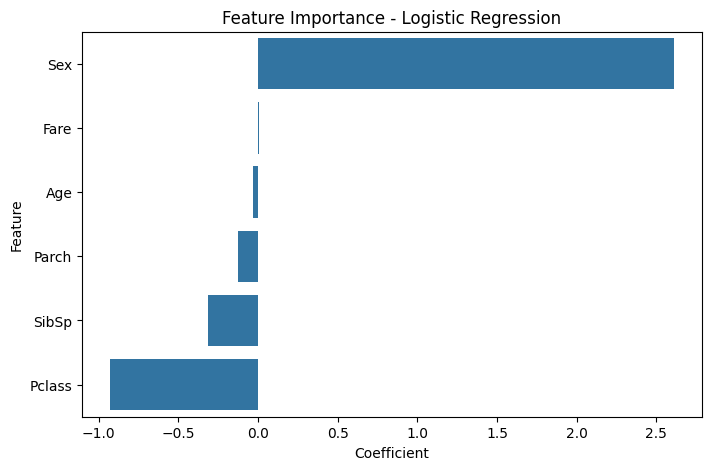

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## 13. Custom Passenger Prediction

A custom prediction function is created to allow the model to predict the survival outcome of an individual passenger based on their details.

In [30]:
def predict_survival(pclass, sex, age, sibsp, parch, fare):
    passenger = [[pclass, sex, age, sibsp, parch, fare]]

    prediction = model.predict(passenger)

    if prediction[0] == 1:
        return "Survived"
    else:
        return "Did not survive"

In [31]:
result = predict_survival(
    pclass=1,
    sex=1,
    age=25,
    sibsp=0,
    parch=0,
    fare=80
)

print("Prediction:", result)

Prediction: Survived


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [32]:
def predict_survival(pclass, sex, age, sibsp, parch, fare):
    passenger = pd.DataFrame([{
        "Pclass": pclass,
        "Sex": sex,
        "Age": age,
        "SibSp": sibsp,
        "Parch": parch,
        "Fare": fare
    }])

    prediction = model.predict(passenger)

    if prediction[0] == 1:
        return "Survived"
    else:
        return "Did not survive"

In [33]:
result = predict_survival(
    pclass=1,
    sex=1,
    age=25,
    sibsp=0,
    parch=0,
    fare=80
)

print("Prediction:", result)

Prediction: Survived


In [34]:
result = predict_survival(
    pclass=3,
    sex=0,
    age=35,
    sibsp=1,
    parch=0,
    fare=10
)

print("Prediction:", result)

Prediction: Did not survive


## 14. Model Saving

The trained Logistic Regression model and its feature names are saved as a `.pkl` file using Joblib.

This allows the trained model to be reused later without retraining it.

In [35]:
import joblib

joblib.dump(model, "titanic_survival_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
import os

print(os.path.exists("titanic_survival_model.pkl"))

True


In [37]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64


In [38]:
print("Features used for prediction:")
print(X.columns.tolist())

Features used for prediction:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']


In [39]:
feature_names = X.columns.tolist()

print("Model features saved:")
print(feature_names)

Model features saved:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']


In [40]:
model_data = {
    "model": model,
    "features": feature_names
}

joblib.dump(model_data, "titanic_survival_model.pkl")

print("Model and feature names saved successfully!")

Model and feature names saved successfully!


In [41]:
saved_data = joblib.load("titanic_survival_model.pkl")

loaded_model = saved_data["model"]
loaded_features = saved_data["features"]

print("Model loaded successfully!")
print("Features:", loaded_features)

Model loaded successfully!
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']


In [42]:
test_passenger = pd.DataFrame([{
    "Pclass": 1,
    "Sex": 1,
    "Age": 25,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 80
}])

prediction = loaded_model.predict(test_passenger)

if prediction[0] == 1:
    print("Prediction: Survived")
else:
    print("Prediction: Did not survive")

Prediction: Survived


In [43]:
print("Final Model Accuracy:", accuracy * 100, "%")

Final Model Accuracy: 81.00558659217877 %


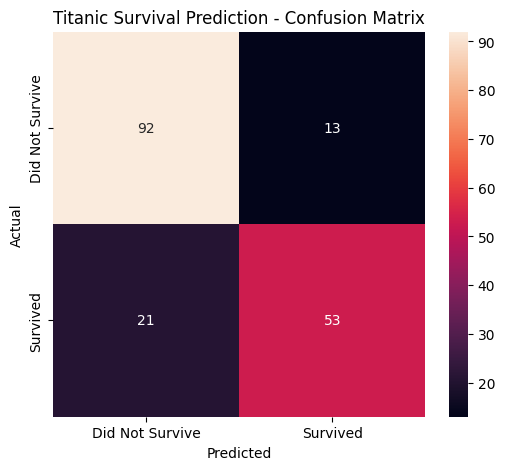

In [44]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Titanic Survival Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 15. Final Results

The Logistic Regression model achieved an accuracy of approximately **81.01%** on the test dataset.

The model performance was further evaluated using precision, recall, F1-score, and a confusion matrix.

In [45]:
print("===== TITANIC SURVIVAL PREDICTION =====")
print()
print("Model: Logistic Regression")
print("Features:", X.columns.tolist())
print(f"Accuracy: {accuracy * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

===== TITANIC SURVIVAL PREDICTION =====

Model: Logistic Regression
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
Accuracy: 81.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## 16. Conclusion

The Titanic Survival Prediction project demonstrates the use of machine learning to predict passenger survival outcomes.

After data cleaning, preprocessing, exploratory data analysis, and feature selection, a Logistic Regression model was trained and evaluated. The model achieved an accuracy of approximately **81.01%** on the test dataset.

The project also demonstrates how passenger characteristics such as gender, passenger class, age, family information, and fare can be used as features for survival prediction.